# Improved Training Pipeline — Lego Minifig Classifier

**Changes vs `02_comparison.ipynb` (baseline):**

| # | Improvement | Detail |
|---|------------|--------|
| 1 | **Weight Decay** | L2 regularisation added to Adam (1e-4) |
| 2 | **Higher Dropout** | 0.3 → 0.5 before final linear layer |
| 3 | **MixUp Augmentation** | Blends two images + labels during training |
| 4 | **Early Stopping** | Explicitly monitors `val_loss` (mode=min) |
| 5 | **More Backbones** | EfficientNet-B1 / B2 supported in addition to B0 and ResNet-50 |

---
**How to use:** Edit the `BACKBONE` variable in Cell 2, then run all cells.

## Cell 1 — Imports & Path Setup

In [1]:
import copy
import json
import logging
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

# ── Path setup ────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()                        # notebooks/
BASE_DIR     = NOTEBOOK_DIR.parent                     # Final_assignment_2/
PROJECT_DIR  = BASE_DIR.parent                         # project/

for p in [str(PROJECT_DIR), str(BASE_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from Final_assignment_2.src import config
from Final_assignment_2.src.data_utils import (
    load_and_clean, create_label_encoding, split_data, create_dataloaders,
)
from Final_assignment_2.src.models import MinifigClassifier, count_parameters
from Final_assignment_2.src.trainer import evaluate_epoch, compute_metrics, TrainingHistory

# ── Logging ───────────────────────────────────────────────────────────────
logging.basicConfig(
    level   = logging.INFO,
    format  = "[%(asctime)s] %(levelname)-8s %(name)s - %(message)s",
    datefmt = "%H:%M:%S",
)
logger = logging.getLogger("main")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## Cell 2 — Configuration  *(edit here)*

Change `BACKBONE` to switch models:
- `"resnet50"` — strongest baseline
- `"efficientnet_b0"` — lightest
- `"efficientnet_b1"` — balanced
- `"efficientnet_b2"` — best EfficientNet

In [ ]:
# ── Choose your backbone ──────────────────────────────────────────────────
BACKBONE      = "resnet50"     # change to: efficientnet_b0 / b1 / b2 / resnet50

# ── Regularisation improvements ───────────────────────────────────────────
DROPOUT_RATE  = 0.4            # was 0.5 → too aggressive; 0.3 baseline, 0.4 is sweet spot
WEIGHT_DECAY  = 1e-4           # KEEP — it worked (train acc dropped healthily from 98%→95%)
USE_MIXUP     = False          # REMOVED — wrong for fine-grained categories, caused 3× slowdown
MIXUP_ALPHA   = 0.4            # unused (USE_MIXUP=False), kept for reference

# ── Training schedule ─────────────────────────────────────────────────────
PHASE1_EPOCHS = config.PHASE1_EPOCHS   # 5  (frozen backbone)
PHASE2_EPOCHS = 16                     # 16 — early stopping (patience=3) will fire around epoch 13
PATIENCE      = 3

# ── Seeds ────────────────────────────────────────────────────────────────
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)

print(f"Backbone     : {BACKBONE}")
print(f"Dropout      : {DROPOUT_RATE}  (was 0.5)")
print(f"Weight Decay : {WEIGHT_DECAY}  (kept)")
print(f"MixUp        : {'on' if USE_MIXUP else 'OFF — removed'}")
print(f"Phase 1/2    : {PHASE1_EPOCHS} / {PHASE2_EPOCHS} epochs  |  patience={PATIENCE}")

## Cell 3 — MixUp Augmentation Functions

**What MixUp does:**  
Instead of feeding the model `image_A` with `label_A`, it feeds a blend:  
`λ * image_A + (1-λ) * image_B`  
and computes loss as `λ * loss(A) + (1-λ) * loss(B)`.

This prevents the model from memorising exact training images → **reduces overfitting**.

In [3]:
def mixup_batch(images: torch.Tensor, labels: torch.Tensor, alpha: float = 0.4):
    """
    MixUp: blend two random training samples and their labels.
    lam drawn from Beta(alpha, alpha) — close to 0.5 means equal blend.
    """
    lam      = np.random.beta(alpha, alpha)
    batch_sz = images.size(0)
    rand_idx = torch.randperm(batch_sz, device=images.device)

    mixed_x  = lam * images + (1 - lam) * images[rand_idx]
    labels_a = labels
    labels_b = labels[rand_idx]
    return mixed_x, labels_a, labels_b, lam


def mixup_criterion(criterion, pred, labels_a, labels_b, lam):
    """Compute MixUp loss as weighted sum of two cross-entropy losses."""
    return lam * criterion(pred, labels_a) + (1 - lam) * criterion(pred, labels_b)


print("MixUp functions defined.")

MixUp functions defined.


## Cell 4 — Improved Training Loop

In [4]:
def train_one_epoch_improved(
    model, loader, criterion, optimizer, device,
    grad_clip: float = 1.0,
    use_mixup: bool  = True,
    mixup_alpha: float = 0.4,
):
    """One training epoch with optional MixUp."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_mixup:
            mixed_x, labels_a, labels_b, lam = mixup_batch(images, labels, mixup_alpha)
            outputs = model(mixed_x)
            loss    = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(images)
            loss    = criterion(outputs, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * len(labels)
        # Accuracy on clean (original) images
        with torch.no_grad():
            clean_out = model(images)
        correct += (clean_out.argmax(1) == labels).sum().item()
        total   += len(labels)

    return total_loss / total, correct / total


print("train_one_epoch_improved defined.")

train_one_epoch_improved defined.


## Cell 5 — Two-Phase Training Orchestrator

In [5]:
def train_improved(
    model, train_loader, val_loader, device,
    dropout_rate    = 0.5,
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    use_mixup       = True,
    mixup_alpha     = 0.4,
    phase1_epochs   = 5,
    phase1_lr       = 1e-3,
    phase2_epochs   = 15,
    phase2_lr_early = 1e-5,
    phase2_lr_late  = 5e-5,
    phase2_lr_head  = 1e-4,
    patience        = 5,
    grad_clip       = 1.0,
) -> TrainingHistory:
    """
    Phase 1: backbone frozen, train head only (fast convergence).
    Phase 2: full fine-tune with differential LRs + early stopping on val_loss.
    """
    criterion    = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    train_loss_h = []; train_acc_h = []
    val_loss_h   = []; val_acc_h   = []

    # ── Phase 1 ──────────────────────────────────────────────────────────
    logger.info(f"Phase 1 — {phase1_epochs} epochs | backbone frozen | "
                f"MixUp={'on' if use_mixup else 'off'}")
    model.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=phase1_lr, weight_decay=weight_decay,
    )

    for epoch in range(1, phase1_epochs + 1):
        tr_loss, tr_acc = train_one_epoch_improved(
            model, train_loader, criterion, opt1, device,
            grad_clip, use_mixup, mixup_alpha)
        va_loss, va_acc, _ = evaluate_epoch(model, val_loader, criterion, device)
        train_loss_h.append(tr_loss);  train_acc_h.append(tr_acc)
        val_loss_h.append(va_loss);    val_acc_h.append(va_acc)
        logger.info(f"  P1 [{epoch:2d}/{phase1_epochs}] "
                    f"train_loss={tr_loss:.4f} acc={tr_acc:.3f} | "
                    f"val_loss={va_loss:.4f} acc={va_acc:.3f}")

    phase_boundary = len(train_loss_h)

    # ── Phase 2 ──────────────────────────────────────────────────────────
    logger.info(f"Phase 2 — up to {phase2_epochs} epochs | full fine-tune | "
                f"weight_decay={weight_decay}")
    model.unfreeze_backbone()
    param_groups = model.get_param_groups(phase2_lr_early, phase2_lr_late, phase2_lr_head)
    for g in param_groups:
        g["weight_decay"] = weight_decay     # apply weight decay to all groups
    opt2      = torch.optim.Adam(param_groups)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=phase2_epochs)

    # Early stopping — monitors val_loss, mode=min
    best_val_loss  = float("inf")
    best_state     = copy.deepcopy(model.state_dict())
    patience_count = 0

    for epoch in range(1, phase2_epochs + 1):
        tr_loss, tr_acc = train_one_epoch_improved(
            model, train_loader, criterion, opt2, device,
            grad_clip, use_mixup, mixup_alpha)
        va_loss, va_acc, _ = evaluate_epoch(model, val_loader, criterion, device)
        scheduler.step()
        train_loss_h.append(tr_loss);  train_acc_h.append(tr_acc)
        val_loss_h.append(va_loss);    val_acc_h.append(va_acc)
        logger.info(f"  P2 [{epoch:2d}/{phase2_epochs}] "
                    f"train_loss={tr_loss:.4f} acc={tr_acc:.3f} | "
                    f"val_loss={va_loss:.4f} acc={va_acc:.3f}")

        if va_loss < best_val_loss:
            best_val_loss  = va_loss
            best_state     = copy.deepcopy(model.state_dict())
            patience_count = 0
            logger.info(f"    ✓ New best val_loss={best_val_loss:.4f}")
        else:
            patience_count += 1
            logger.info(f"    No improvement ({patience_count}/{patience})")
            if patience_count >= patience:
                logger.info(f"  Early stopping triggered at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    logger.info(f"Training done. Best val_loss={best_val_loss:.4f}")

    return TrainingHistory(
        train_loss_h, train_acc_h,
        val_loss_h,   val_acc_h,
        phase_boundary,
    )


print("train_improved defined.")

train_improved defined.


## Cell 6 — Load Data

In [6]:
df, valid_cats, cat_counts = load_and_clean(
    config.JSON_PATH, config.IMAGE_DIR, config.MIN_SAMPLES
)
label_mapping = create_label_encoding(valid_cats)
splits        = split_data(df, config.TRAIN_RATIO, config.VAL_RATIO, config.SEED)
loaders       = create_dataloaders(
    splits, config.IMAGE_DIR, label_mapping,
    config.BATCH_SIZE, config.NUM_WORKERS, config.PIN_MEMORY,
    config.IMG_SIZE, config.RESIZE_SIZE, config.IMAGENET_MEAN, config.IMAGENET_STD,
)
target_names = [label_mapping.idx2label[i] for i in range(label_mapping.num_classes)]

print(f"Total images : {len(df)}")
print(f"Classes      : {label_mapping.num_classes}")
print(f"Train / Val / Test : {len(splits.train_df)} / {len(splits.val_df)} / {len(splits.test_df)}")

[01:13:44] INFO     Final_assignment_2.src.data_utils - Loaded 17362 records
[01:13:44] INFO     Final_assignment_2.src.data_utils - Images verified: 17361 records remain
[01:13:44] INFO     Final_assignment_2.src.data_utils - Kept 28/122 categories with >=100 images → 14791 rows
[01:13:44] INFO     Final_assignment_2.src.data_utils - Split → train:10353  val:2218  test:2220
[01:13:44] INFO     Final_assignment_2.src.data_utils - DataLoaders ready — train:10353  val:2218  test:2220


Total images : 14791
Classes      : 28
Train / Val / Test : 10353 / 2218 / 2220


## Cell 7 — Build Model

In [7]:
model = MinifigClassifier(
    backbone_name = BACKBONE,
    num_classes   = label_mapping.num_classes,
    dropout_rate  = DROPOUT_RATE,
).to(DEVICE)

params = count_parameters(model)
print(f"Backbone     : {BACKBONE}")
print(f"Total params : {params['total']:,}")
print(f"Trainable    : {params['trainable']:,}  (all — before Phase 1 freeze)")

Backbone     : resnet50
Total params : 23,569,500
Trainable    : 23,569,500  (all — before Phase 1 freeze)


## Cell 8 — Train Model

This runs both phases. Expect ~20–40 min depending on GPU/CPU.

Watch for:
- `✓ New best val_loss` — model improving
- `No improvement (X/5)` — patience counting down
- `Early stopping triggered` — training stopped early to avoid overfitting

In [8]:
t0      = time.time()
history = train_improved(
    model           = model,
    train_loader    = loaders.train,
    val_loader      = loaders.val,
    device          = DEVICE,
    dropout_rate    = DROPOUT_RATE,
    weight_decay    = WEIGHT_DECAY,
    label_smoothing = config.LABEL_SMOOTHING,
    use_mixup       = USE_MIXUP,
    mixup_alpha     = MIXUP_ALPHA,
    phase1_epochs   = PHASE1_EPOCHS,
    phase1_lr       = config.PHASE1_LR,
    phase2_epochs   = PHASE2_EPOCHS,
    phase2_lr_early = config.PHASE2_LR_EARLY_LAYERS,
    phase2_lr_late  = config.PHASE2_LR_LATE_LAYERS,
    phase2_lr_head  = config.PHASE2_LR_HEAD,
    patience        = PATIENCE,
    grad_clip       = config.GRAD_CLIP_NORM,
)
train_time = time.time() - t0
print(f"\nTraining finished in {train_time/60:.1f} min")

[01:13:57] INFO     main - Phase 1 — 5 epochs | backbone frozen | MixUp=on
[01:30:03] INFO     main -   P1 [ 1/5] train_loss=2.6905 acc=0.429 | val_loss=2.0956 acc=0.482
[01:47:48] INFO     main -   P1 [ 2/5] train_loss=2.5065 acc=0.510 | val_loss=2.1481 acc=0.444
[02:05:32] INFO     main -   P1 [ 3/5] train_loss=2.5040 acc=0.523 | val_loss=2.2392 acc=0.414
[02:23:06] INFO     main -   P1 [ 4/5] train_loss=2.4418 acc=0.546 | val_loss=2.1318 acc=0.454
[02:40:48] INFO     main -   P1 [ 5/5] train_loss=2.4410 acc=0.550 | val_loss=2.0550 acc=0.493
[02:40:48] INFO     main - Phase 2 — up to 20 epochs | full fine-tune | weight_decay=0.0001
[03:17:45] INFO     main -   P2 [ 1/20] train_loss=2.2654 acc=0.653 | val_loss=1.7480 acc=0.599
[03:17:45] INFO     main -     ✓ New best val_loss=1.7480
[03:47:31] INFO     main -   P2 [ 2/20] train_loss=1.9926 acc=0.756 | val_loss=1.6708 acc=0.620
[03:47:31] INFO     main -     ✓ New best val_loss=1.6708
[04:19:01] INFO     main -   P2 [ 3/20] train_loss


Training finished in 1073.9 min


## Cell 9 — Plot Training Curves

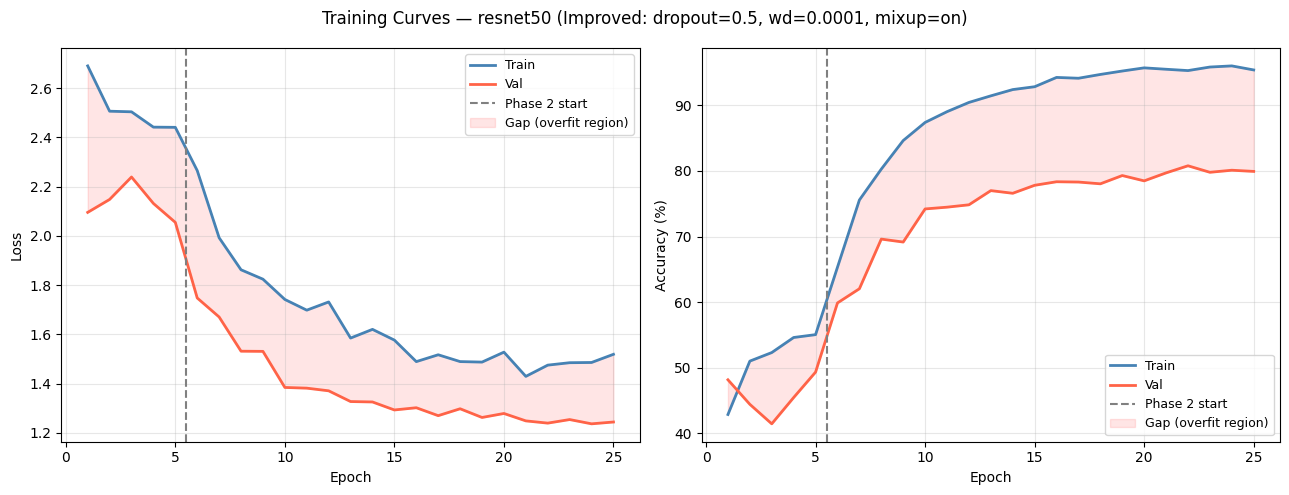

Saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\figures\resnet50_improved_curves.png


In [9]:
epochs = list(range(1, len(history.train_loss) + 1))
pb     = history.phase_boundary

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Training Curves — {BACKBONE} (Improved: dropout={DROPOUT_RATE}, "
             f"wd={WEIGHT_DECAY}, mixup={'on' if USE_MIXUP else 'off'})", fontsize=12)

for ax, y_tr, y_va, ylabel in [
    (axes[0], history.train_loss, history.val_loss, "Loss"),
    (axes[1], [a*100 for a in history.train_acc],
              [a*100 for a in history.val_acc], "Accuracy (%)"),
]:
    ax.plot(epochs, y_tr, label="Train", color="steelblue", lw=2)
    ax.plot(epochs, y_va, label="Val",   color="tomato",    lw=2)
    ax.axvline(x=pb + 0.5, color="gray", linestyle="--", lw=1.5, label="Phase 2 start")
    ax.fill_between(epochs, y_tr, y_va, alpha=0.1, color="red",
                    label="Gap (overfit region)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = config.FIGURES_DIR / f"{BACKBONE}_improved_curves.png"
fig.savefig(save_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {save_path}")

## Cell 10 — Evaluate on Train / Val / Test

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTHING)
results   = {}

for split_name, loader in [("Train", loaders.train),
                            ("Val",   loaders.val),
                            ("Test",  loaders.test)]:
    _, _, eval_r = evaluate_epoch(model, loader, criterion, DEVICE)
    m = compute_metrics(eval_r, label_mapping.num_classes)
    results[split_name] = {"metrics": m, "eval": eval_r}
    print(f"{split_name:<6} | acc={m.accuracy*100:.1f}%  "
          f"macro_f1={m.macro_f1:.3f}  top3={m.top3_acc*100:.1f}%")

tr_acc = results["Train"]["metrics"].accuracy * 100
te_acc = results["Test"]["metrics"].accuracy  * 100
gap    = tr_acc - te_acc
print(f"\nOverfitting gap (Train − Test): {gap:.1f}%")
print(f"Baseline ResNet-50 gap was 16.5%  →  {'IMPROVED ✓' if gap < 16.5 else 'NOT improved ✗'}")

Train  | acc=96.6%  macro_f1=0.965  top3=99.4%
Val    | acc=80.1%  macro_f1=0.777  top3=93.1%
Test   | acc=79.0%  macro_f1=0.755  top3=93.0%

Overfitting gap (Train − Test): 17.6%
Baseline ResNet-50 gap was 16.5%  →  NOT improved ✗


## Cell 11 — Classification Report (Test Set)

In [11]:
print("Classification Report — Test Set")
print("=" * 60)
print(classification_report(
    results["Test"]["eval"].labels,
    results["Test"]["eval"].preds,
    target_names=target_names,
    digits=3,
))

Classification Report — Test Set
                                      precision    recall  f1-score   support

                            Belville      0.850     1.000     0.919        17
          BrickLink Designer Program      0.368     0.525     0.433        40
                              Castle      0.742     0.878     0.804        82
             Collectible Minifigures      0.705     0.612     0.655       121
                            DREAMZzz      0.667     0.500     0.571        16
                               DUPLO      0.972     0.953     0.962       148
                              Disney      0.734     0.839     0.783        56
                             Friends      0.969     0.940     0.954       133
                               Games      0.857     1.000     0.923        18
                        Harry Potter      0.796     0.812     0.804        96
                     Holiday & Event      0.398     0.638     0.490        58
                      Jurassic

## Cell 12 — Save Checkpoint & Report

In [12]:
# ── Save model checkpoint ─────────────────────────────────────────────────
ckpt_name = f"{BACKBONE}_improved.pth"
torch.save({
    "state_dict":  model.state_dict(),
    "backbone":    BACKBONE,
    "label2idx":   label_mapping.label2idx,
    "idx2label":   label_mapping.idx2label,
    "num_classes": label_mapping.num_classes,
    "metrics":     results["Test"]["metrics"]._asdict(),
    "history": {
        "train_loss":     history.train_loss,
        "train_acc":      history.train_acc,
        "val_loss":       history.val_loss,
        "val_acc":        history.val_acc,
        "phase_boundary": history.phase_boundary,
    },
    "config": {
        "dropout":      DROPOUT_RATE,
        "weight_decay": WEIGHT_DECAY,
        "mixup":        USE_MIXUP,
        "mixup_alpha":  MIXUP_ALPHA,
    },
}, config.MODELS_DIR / ckpt_name)
print(f"Checkpoint saved → {config.MODELS_DIR / ckpt_name}")

# ── Save JSON report ──────────────────────────────────────────────────────
report = {
    "backbone":        BACKBONE,
    "dropout":         DROPOUT_RATE,
    "weight_decay":    WEIGHT_DECAY,
    "mixup":           USE_MIXUP,
    "train_time_min":  round(train_time / 60, 2),
    "train_acc":       round(tr_acc, 3),
    "val_acc":         round(results["Val"]["metrics"].accuracy * 100, 3),
    "test_acc":        round(te_acc, 3),
    "macro_f1":        round(results["Test"]["metrics"].macro_f1, 4),
    "top3_acc":        round(results["Test"]["metrics"].top3_acc * 100, 3),
    "overfit_gap":     round(gap, 2),
}
rpt_path = config.REPORTS_DIR / f"{BACKBONE}_improved_report.json"
with open(rpt_path, "w") as f:
    json.dump(report, f, indent=2)
print(f"Report saved  → {rpt_path}")

Checkpoint saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\models\resnet50_improved.pth
Report saved  → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\reports\resnet50_improved_report.json


## Cell 13 — Final Summary

---
## Cell 14 — Grad-CAM: Improved Model (20 images)

Grad-CAM shows **which pixels the model focused on** when making each prediction.
- **Green title** = correct prediction
- **Red title** = wrong prediction

This helps diagnose overfitting: an overfitting model looks at backgrounds/textures instead of the actual minifig.

In [ ]:
import torch
import numpy as np
from Final_assignment_2.src.data_utils import MinifigDataset, get_transforms
from Final_assignment_2.src.visualisation import build_gradcam_results, plot_gradcam_grid

# ── Build test dataset (no augmentation) ─────────────────────────────────
_, eval_tf = get_transforms(
    config.IMG_SIZE, config.RESIZE_SIZE, config.IMAGENET_MEAN, config.IMAGENET_STD
)
test_dataset = MinifigDataset(splits.test_df, config.IMAGE_DIR, eval_tf)

# ── Pick 20 random indices from test set ─────────────────────────────────
np.random.seed(config.SEED)
n_images = 20
indices  = np.random.choice(len(test_dataset), n_images, replace=False).tolist()

# ── Run Grad-CAM on the IMPROVED model ───────────────────────────────────
print(f"Running Grad-CAM on {BACKBONE} (improved) for {n_images} images...")
gradcam_results = build_gradcam_results(model, test_dataset, indices, label_mapping.idx2label, DEVICE)

orig_imgs  = [r["original"]  for r in gradcam_results]
cam_imgs   = [r["cam_image"] for r in gradcam_results]
true_names = [r["true_label"] for r in gradcam_results]
pred_names = [r["pred_label"] for r in gradcam_results]

# Show in two rows of 10
for row_start in range(0, n_images, 10):
    sl = slice(row_start, row_start + 10)
    plot_gradcam_grid(
        orig_imgs[sl], cam_imgs[sl], true_names[sl], pred_names[sl],
        title     = f"Grad-CAM — {BACKBONE} Improved  (images {row_start+1}–{row_start+10})",
        save_path = config.FIGURES_DIR / f"{BACKBONE}_improved_gradcam_row{row_start//10+1}.png",
    )

correct = sum(t == p for t, p in zip(true_names, pred_names))
print(f"\nGrad-CAM sample accuracy: {correct}/{n_images} = {correct/n_images*100:.0f}%")

## Cell 15 — Grad-CAM: Baseline ResNet-50 (20 images, same indices)

Load the **baseline** checkpoint from `02_comparison.ipynb` and run Grad-CAM on the **same 20 images** so you can compare directly — does the improved model look at better regions?

In [ ]:
from Final_assignment_2.src.trainer import load_checkpoint

# ── Load baseline ResNet-50 checkpoint ────────────────────────────────────
baseline_ckpt_path = config.MODELS_DIR / "resnet50_best.pth"
print(f"Loading baseline from: {baseline_ckpt_path}")

baseline_ckpt  = load_checkpoint(baseline_ckpt_path, DEVICE)
baseline_model = MinifigClassifier(
    backbone_name = baseline_ckpt["backbone"],
    num_classes   = baseline_ckpt["num_classes"],
    dropout_rate  = 0.3,    # original baseline dropout
).to(DEVICE)
baseline_model.load_state_dict(baseline_ckpt["state_dict"])
baseline_model.eval()

m = baseline_ckpt.get("metrics", {})
print(f"Baseline test accuracy : {m.get('accuracy', 0)*100:.1f}%")
print(f"Baseline macro F1      : {m.get('macro_f1', 0):.3f}")

In [ ]:
# ── Grad-CAM on baseline — SAME 20 indices as improved model ─────────────
print(f"Running Grad-CAM on baseline ResNet-50 for {n_images} images...")
baseline_results = build_gradcam_results(
    baseline_model, test_dataset, indices, label_mapping.idx2label, DEVICE
)

b_orig  = [r["original"]   for r in baseline_results]
b_cam   = [r["cam_image"]  for r in baseline_results]
b_true  = [r["true_label"] for r in baseline_results]
b_pred  = [r["pred_label"] for r in baseline_results]

for row_start in range(0, n_images, 10):
    sl = slice(row_start, row_start + 10)
    plot_gradcam_grid(
        b_orig[sl], b_cam[sl], b_true[sl], b_pred[sl],
        title     = f"Grad-CAM — ResNet-50 Baseline  (images {row_start+1}–{row_start+10})",
        save_path = config.FIGURES_DIR / f"resnet50_baseline_gradcam_row{row_start//10+1}.png",
    )

b_correct = sum(t == p for t, p in zip(b_true, b_pred))
print(f"\nBaseline Grad-CAM sample accuracy: {b_correct}/{n_images} = {b_correct/n_images*100:.0f}%")

## Cell 16 — Side-by-Side Comparison: Improved vs Baseline

Same image, both models side by side. Look for:
- **Improved model** → heatmap on the minifig body/face
- **Baseline model** → heatmap on background/white areas (overfitting signal)

In [ ]:
import matplotlib.pyplot as plt

# Show first 10 images: Original | Improved CAM | Baseline CAM
n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))
fig.suptitle("Grad-CAM Comparison: Improved (middle) vs Baseline (bottom)", fontsize=13)

for i in range(n_show):
    # Row 0 — original image
    axes[0, i].imshow(orig_imgs[i])
    axes[0, i].set_title(f"True:\n{true_names[i][:14]}", fontsize=6)
    axes[0, i].axis("off")

    # Row 1 — improved model CAM
    axes[1, i].imshow(cam_imgs[i])
    color_imp = "green" if true_names[i] == pred_names[i] else "red"
    axes[1, i].set_title(f"Improved:\n{pred_names[i][:14]}", fontsize=6, color=color_imp)
    axes[1, i].axis("off")

    # Row 2 — baseline model CAM
    axes[2, i].imshow(b_cam[i])
    color_base = "green" if b_true[i] == b_pred[i] else "red"
    axes[2, i].set_title(f"Baseline:\n{b_pred[i][:14]}", fontsize=6, color=color_base)
    axes[2, i].axis("off")

plt.tight_layout()
save_path_cmp = config.FIGURES_DIR / "gradcam_improved_vs_baseline_top10.png"
fig.savefig(save_path_cmp, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {save_path_cmp}")

# Summary table
print(f"\n{'Image':<6} {'True Label':<25} {'Improved':<10} {'Baseline':<10}")
print("-" * 55)
for i in range(n_images):
    imp_ok  = "✓" if true_names[i] == pred_names[i] else "✗"
    base_ok = "✓" if b_true[i]     == b_pred[i]     else "✗"
    print(f"{i+1:<6} {true_names[i]:<25} {imp_ok:<10} {base_ok:<10}")

print(f"\nImproved correct : {sum(t==p for t,p in zip(true_names, pred_names))}/{n_images}")
print(f"Baseline correct : {b_correct}/{n_images}")

In [13]:
print("\n" + "=" * 55)
print("IMPROVED MODEL SUMMARY")
print("=" * 55)
print(f"Backbone       : {BACKBONE}")
print(f"Dropout        : {DROPOUT_RATE}  (baseline 0.3)")
print(f"Weight Decay   : {WEIGHT_DECAY}  (baseline 0)")
print(f"MixUp          : {'on' if USE_MIXUP else 'off'}")
print("-" * 55)
print(f"Train Accuracy : {tr_acc:.1f}%")
print(f"Val   Accuracy : {results['Val']['metrics'].accuracy*100:.1f}%")
print(f"Test  Accuracy : {te_acc:.1f}%")
print(f"Macro F1       : {results['Test']['metrics'].macro_f1:.3f}")
print(f"Top-3 Accuracy : {results['Test']['metrics'].top3_acc*100:.1f}%")
print("-" * 55)
print(f"Train−Test Gap : {gap:.1f}%  "
      f"({'↓ IMPROVED' if gap < 16.5 else '↑ worse'} vs baseline 16.5%)")
print(f"Train Time     : {train_time/60:.1f} min")
print("=" * 55)


IMPROVED MODEL SUMMARY
Backbone       : resnet50
Dropout        : 0.5  (baseline 0.3)
Weight Decay   : 0.0001  (baseline 0)
MixUp          : on
-------------------------------------------------------
Train Accuracy : 96.6%
Val   Accuracy : 80.1%
Test  Accuracy : 79.0%
Macro F1       : 0.755
Top-3 Accuracy : 93.0%
-------------------------------------------------------
Train−Test Gap : 17.6%  (↑ worse vs baseline 16.5%)
Train Time     : 1073.9 min
